# Postprocessing: gap scan + Bx profile + multipoles (all cases)

This notebook scans `../runs/case_*/out/` and reproduces the same core plots as the JUAS/NCMagnets workflow,
plus extra diagnostics (multipoles + monitors).


In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

RUNS_DIR = Path('..')/'runs'
case_dirs = sorted([p for p in RUNS_DIR.glob('case_*') if p.is_dir()])
len(case_dirs), case_dirs[:3]

(5,
 [PosixPath('../runs/case_0001'),
  PosixPath('../runs/case_0002'),
  PosixPath('../runs/case_0003')])

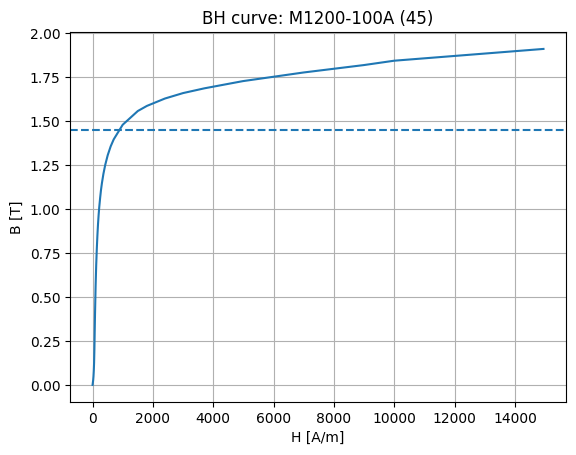

In [2]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Plot the BH curve used for laminated steel (optional in FEMM runs)
bh_path = Path('..') / 'materials' / 'M1200-100A_45.dat'
if bh_path.exists():
    bh = pd.read_csv(bh_path, sep=r'\s+', header=None, names=['B_T','H_Am'])
    plt.figure()
    plt.plot(bh['H_Am'], bh['B_T'])
    plt.axhline(1.45, linestyle='--')
    plt.xlabel('H [A/m]')
    plt.ylabel('B [T]')
    plt.grid(True)
    plt.title('BH curve: M1200-100A (45)')
    plt.show()
else:
    print('BH curve file not found:', bh_path)


In [3]:
def load_case(case_dir: Path):
    out = case_dir/'out'
    gap = out/'gap_By_scan.csv'
    mul = out/'multipoles.csv'
    df_gap = pd.read_csv(gap) if gap.exists() else None
    df_mul = pd.read_csv(mul) if mul.exists() else None
    return df_gap, df_mul

cases=[]
for c in case_dirs:
    g,m = load_case(c)
    if g is None:
        continue
    cases.append((c.name,g,m))
len(cases)

5

In [4]:
def summarize_gap(df):
    idx0 = (df['x_mm'].abs()).idxmin()
    By0 = float(df.loc[idx0,'By_T'])
    d = df['dBy_over_By0'].astype(float)
    return By0, float(d.abs().max()), float((d**2).mean()**0.5)

def summarize_multipoles(df_mul):
    if df_mul is None:
        return {}
    m = {int(r['n']): float(r['Cn_over_fund']) for _,r in df_mul.iterrows()}
    return {'b3/b1': m.get(3, float('nan')),
            'b5/b1': m.get(5, float('nan')),
            'b7/b1': m.get(7, float('nan'))}

rows=[]
for name,df_gap,df_mul in cases:
    By0,maxabs,rms = summarize_gap(df_gap)
    row={'case':name,'By0_T':By0,'max|dBy/By0|':maxabs,'rms(dBy/By0)':rms}
    row.update(summarize_multipoles(df_mul))
    rows.append(row)

summary = pd.DataFrame(rows).sort_values('case').reset_index(drop=True)
summary

,case,By0_T,max|dBy/By0|,rms(dBy/By0),b3/b1,b5/b1,b7/b1
0,case_0001,-0.390653,0.212365,0.179742,0.541810,0.201566,0.188340
1,case_0002,-0.414268,0.201257,0.168032,0.542445,0.200769,0.188935
2,case_0003,-0.433792,0.201186,0.168133,0.542462,0.200785,0.188914
3,case_0004,-0.448138,0.214391,0.180923,0.542930,0.201400,0.188130
4,case_0005,-0.466906,0.215290,0.180898,0.542929,0.201536,0.188043


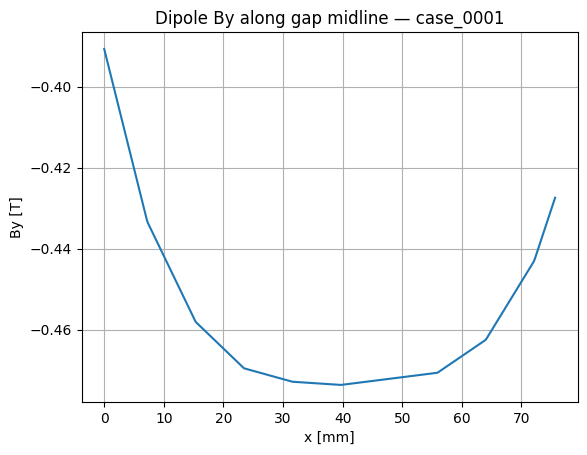

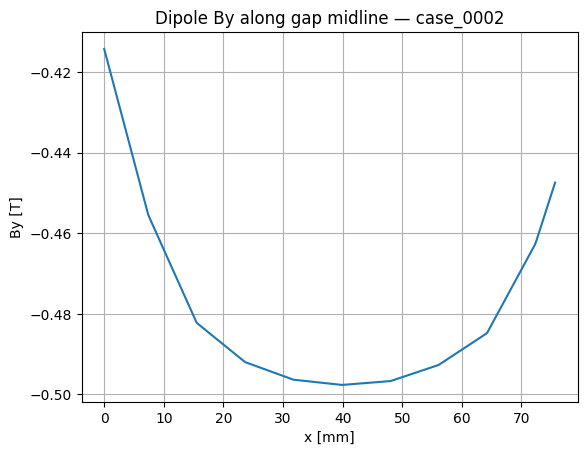

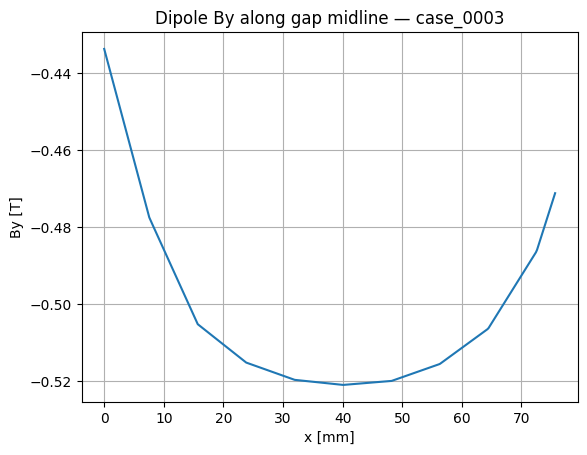

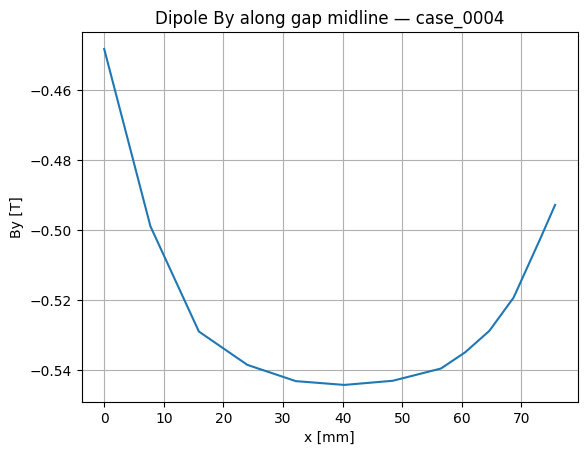

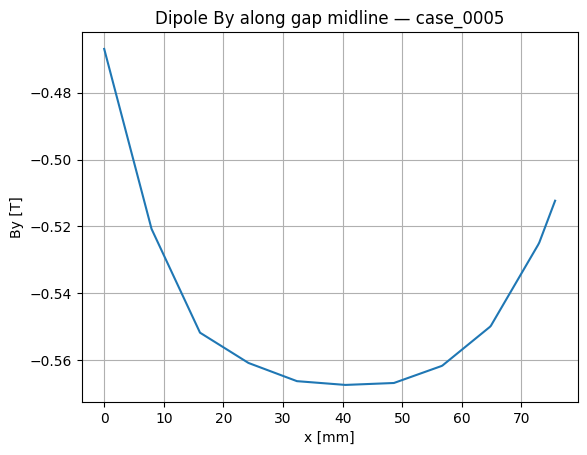

In [5]:
for name,df_gap,_ in cases[:5]:
    plt.figure()
    plt.plot(df_gap['x_mm'], df_gap['By_T'])
    plt.xlabel('x [mm]'); plt.ylabel('By [T]'); plt.grid(True)
    plt.title(f'Dipole By along gap midline — {name}')
plt.show()

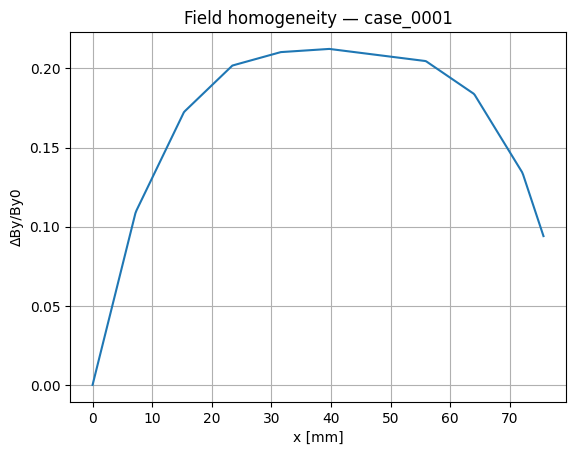

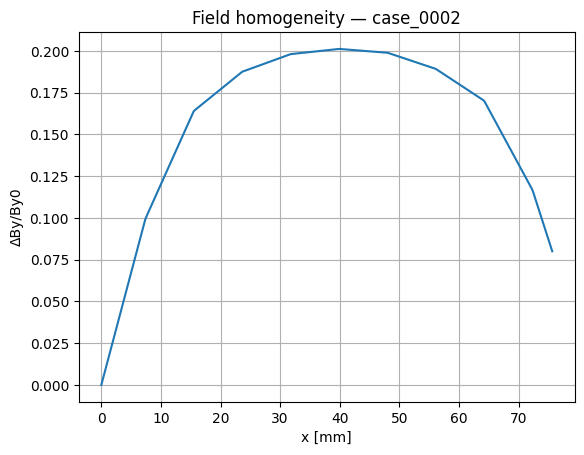

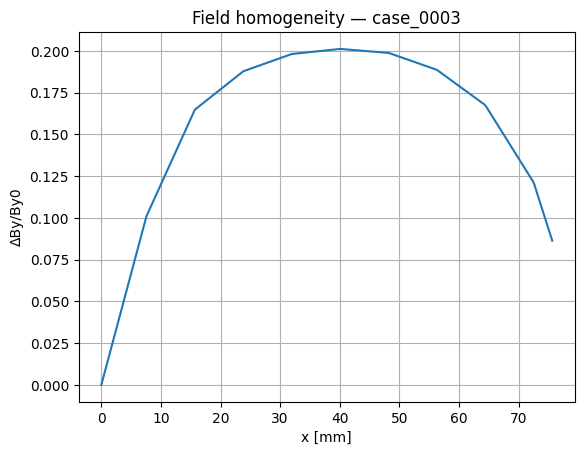

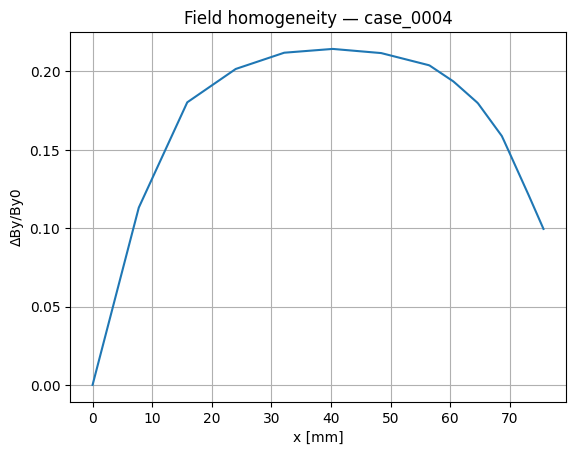

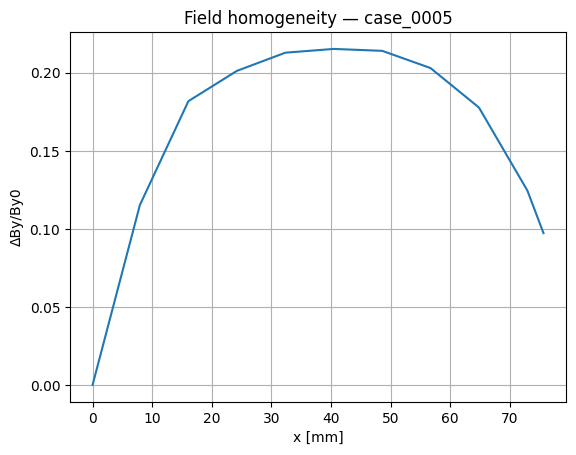

In [6]:
for name,df_gap,_ in cases[:5]:
    plt.figure()
    plt.plot(df_gap['x_mm'], df_gap['dBy_over_By0'])
    plt.xlabel('x [mm]'); plt.ylabel('ΔBy/By0'); plt.grid(True)
    plt.title(f'Field homogeneity — {name}')
plt.show()

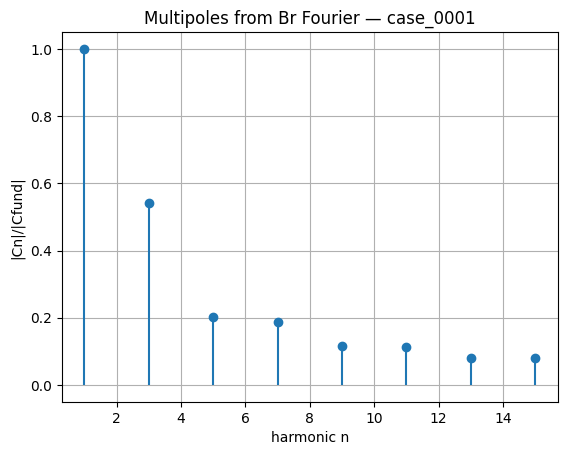

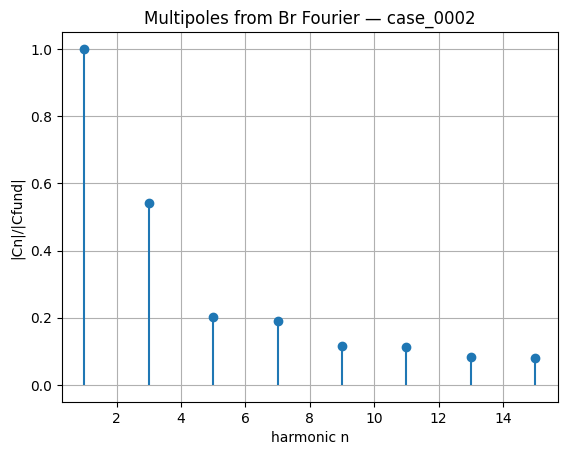

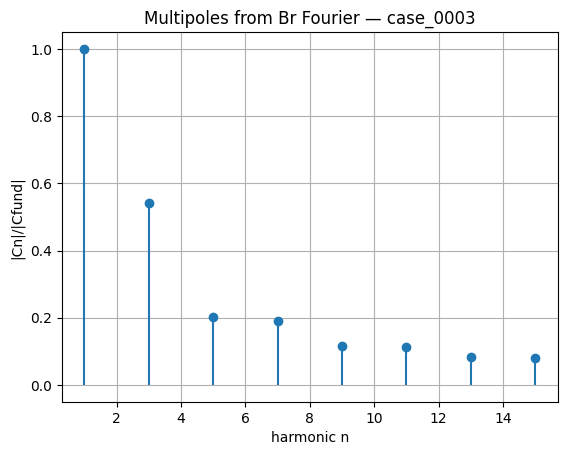

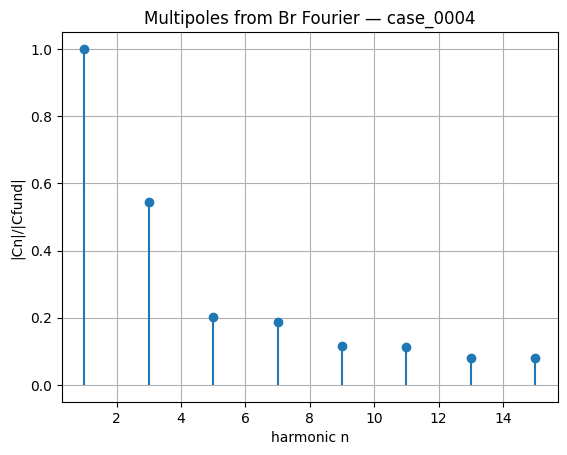

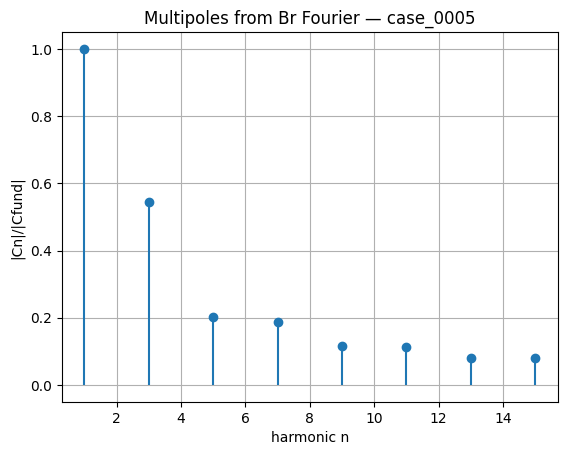

In [7]:
for name,_,df_mul in cases[:5]:
    if df_mul is None: continue
    plt.figure()
    plt.stem(df_mul['n'], df_mul['Cn_over_fund'], basefmt=' ')
    plt.xlabel('harmonic n'); plt.ylabel('|Cn|/|Cfund|'); plt.grid(True)
    plt.title(f'Multipoles from Br Fourier — {name}')
plt.show()

In [8]:
summary.to_csv('summary_cases.csv', index=False)
Path('summary_cases.csv').resolve()

PosixPath('/Users/leogrossman/Desktop/JUAS26-Course2-NC-Mag-Case-Study/postprocessing/summary_cases.csv')

In [9]:
# Plot tutorial-style transverse Bx profile for one case
case_dir = runs[0] if runs else None
if case_dir is not None:
    bx_file = case_dir / 'out' / 'Bx_profile.txt'
    if bx_file.exists():
        bx = pd.read_csv(bx_file, sep=r'\s+', header=None, names=['x_mm','Bx_T'])
        B0 = bx['Bx_T'].iloc[0]
        denom = abs(B0) if abs(B0) > 0 else 1.0
        delta_log10 = ((bx['Bx_T'] - B0).abs()/denom + 1e-300).apply(lambda v: math.log10(v))

        plt.figure()
        plt.plot(bx['x_mm'], bx['Bx_T'])
        plt.xlabel('x [mm]')
        plt.ylabel('Bx [T]')
        plt.grid(True)
        plt.title(f'Bx profile (case {case_dir.name})')
        plt.show()

        plt.figure()
        plt.plot(bx['x_mm'], delta_log10)
        plt.xlabel('x [mm]')
        plt.ylabel(r'log10(|Bx-B0|/|B0|)')
        plt.grid(True)
        plt.title(f'Field quality from Bx profile (case {case_dir.name})')
        plt.show()
    else:
        print('Missing:', bx_file)


NameError: name 'runs' is not defined